## Parallelization

LangGraph에서 여러 노드를 **동시에** 실행하는 방법을 배운다.

In [3]:
import operator
import time
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

load_dotenv()

MODEL_NAME = "gemini-3.6-flash"

### 병렬 처리가 필요한 이유

하나의 문서를 3개 관점(법률, 재무, 기술)으로 분석한다고 하자.

**순차 처리:**
```
법률 분석 (3초) → 재무 분석 (3초) → 기술 분석 (3초) = 총 9초
```

**병렬 처리:**
```
법률 분석 (3초) ─┐
재무 분석 (3초) ─┼→ 종합 = 총 3초 + α
기술 분석 (3초) ─┘
```

분석 관점이 서로 독립적이면 작업 간 의존성을 깨뜨리지 않고 병렬로 실행할 수 있다. 단, LLM의 응답 내용과 병렬 결과가 합쳐지는 순서는 실행할 때마다 달라질 수 있다. LangGraph는 이런 병렬 실행을 **그래프 구조**로 자연스럽게 표현한다.

### 기본 병렬 노드 (Fan-out / Fan-in)

하나의 노드 뒤에 여러 노드를 연결하면 LangGraph가 자동으로 **병렬 실행**한다.

```
START ─┬→ legal_analysis     ─┐
       ├→ financial_analysis ─┼→ summarize → END
       └→ technical_analysis ─┘
```

핵심: State에 `Annotated[list, operator.add]`를 사용해서 각 노드의 결과를 **하나의 리스트에 누적**한다.

In [4]:
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)


class AnalysisState(TypedDict):
    document: str
    analyses: Annotated[list, operator.add]  # 각 분석 결과가 누적됨
    summary: str


def legal_analysis(state: AnalysisState):
    result = llm.invoke(
        f"다음 문서를 법률 관점에서 핵심 리스크 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    print("[legal_analysis] 완료")
    return {"analyses": [f"[법률] {result.text}"]}


def financial_analysis(state: AnalysisState):
    result = llm.invoke(
        f"다음 문서를 재무 관점에서 핵심 포인트 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    print("[financial_analysis] 완료")
    return {"analyses": [f"[재무] {result.text}"]}


def technical_analysis(state: AnalysisState):
    result = llm.invoke(
        f"다음 문서를 기술 관점에서 핵심 포인트 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    print("[technical_analysis] 완료")
    return {"analyses": [f"[기술] {result.text}"]}


def summarize(state: AnalysisState):
    all_analyses = "\n\n".join(state["analyses"])
    result = llm.invoke(
        f"다음 3가지 관점의 분석을 종합해서 3줄로 요약해줘:\n\n{all_analyses}"
    )
    return {"summary": result.text}

In [ ]:
graph_builder = StateGraph(AnalysisState)

graph_builder.add_node("legal_analysis", legal_analysis)
graph_builder.add_node("financial_analysis", financial_analysis)
graph_builder.add_node("technical_analysis", technical_analysis)
graph_builder.add_node("summarize", summarize)

# Fan-out: START → 3개 분석 노드 (병렬)
graph_builder.add_edge(START, "legal_analysis")
graph_builder.add_edge(START, "financial_analysis")
graph_builder.add_edge(START, "technical_analysis")

# Fan-in: 3개 분석 노드가 모두 완료된 뒤 summarize 실행
graph_builder.add_edge(
    ["legal_analysis", "financial_analysis", "technical_analysis"],
    "summarize",
)
graph_builder.add_edge("summarize", END)

analysis_graph = graph_builder.compile()
display(Image(analysis_graph.get_graph().draw_mermaid_png()))

In [ ]:
document = """AI 스타트업 A사가 시리즈B 투자 500억원을 유치했다.
핵심 기술은 자체 개발한 경량 LLM으로, 기존 모델 대비 추론 속도가 3배 빠르다.
다만 학습 데이터의 저작권 문제가 일부 제기되고 있으며,
현재 매출 대비 기업가치가 100배 수준이라는 지적도 있다.
올해 하반기 상용화를 목표로 하고 있다."""

start = time.perf_counter()
result = {"analyses": []}
for event in analysis_graph.stream(
    {"document": document}, stream_mode="updates"
):
    for node_name, update in event.items():
        print(f"[노드 완료] {node_name} -> {list(update.keys())}")
        if "analyses" in update:
            result["analyses"].extend(update["analyses"])
        if "summary" in update:
            result["summary"] = update["summary"]
elapsed = time.perf_counter() - start

print(f"\n소요 시간: {elapsed:.1f}초")
print(f"\n=== 분석 결과 ({len(result['analyses'])}개) ===")
for a in result["analyses"]:
    print(a)
    print()
print(f"=== 종합 ===")
print(result["summary"])

### 결과 순서가 필요할 때

병렬 노드의 결과는 어떤 노드가 먼저 끝나느냐에 따라 순서가 달라진다. 순서가 중요하면 결과에 **식별자를 포함**시키고 후처리에서 정렬하면 된다.

위 예제의 분석 노드를 수정해서, 결과를 `(순서, 내용)` 튜플로 반환하고 `summarize`에서 정렬하는 방식이다.

In [ ]:
class OrderedAnalysisState(TypedDict):
    document: str
    analyses: Annotated[list, operator.add]  # (순서, 내용) 튜플이 누적됨
    summary: str


def ordered_legal(state: OrderedAnalysisState):
    result = llm.invoke(
        f"다음 문서를 법률 관점에서 핵심 리스크 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    return {"analyses": [(0, f"[법률] {result.text}")]}


def ordered_financial(state: OrderedAnalysisState):
    result = llm.invoke(
        f"다음 문서를 재무 관점에서 핵심 포인트 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    return {"analyses": [(1, f"[재무] {result.text}")]}


def ordered_technical(state: OrderedAnalysisState):
    result = llm.invoke(
        f"다음 문서를 기술 관점에서 핵심 포인트 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    return {"analyses": [(2, f"[기술] {result.text}")]}


def ordered_summarize(state: OrderedAnalysisState):
    # 순서대로 정렬
    sorted_analyses = sorted(state["analyses"], key=lambda x: x[0])
    print("정렬된 순서:")
    for order, content in sorted_analyses:
        print(f"  {order}: {content[:30]}...")

    all_analyses = "\n\n".join(content for _, content in sorted_analyses)
    result = llm.invoke(
        f"다음 3가지 관점의 분석을 종합해서 3줄로 요약해줘:\n\n{all_analyses}"
    )
    return {"summary": result.text}


graph_builder = StateGraph(OrderedAnalysisState)
graph_builder.add_node("legal", ordered_legal)
graph_builder.add_node("financial", ordered_financial)
graph_builder.add_node("technical", ordered_technical)
graph_builder.add_node("summarize", ordered_summarize)

graph_builder.add_edge(START, "legal")
graph_builder.add_edge(START, "financial")
graph_builder.add_edge(START, "technical")
graph_builder.add_edge(["legal", "financial", "technical"], "summarize")
graph_builder.add_edge("summarize", END)

ordered_graph = graph_builder.compile()

result = {"analyses": []}
for event in ordered_graph.stream(
    {"document": document}, stream_mode="updates"
):
    for node_name, update in event.items():
        print(f"[노드 완료] {node_name} -> {list(update.keys())}")
        if "analyses" in update:
            result["analyses"].extend(update["analyses"])
        if "summary" in update:
            result["summary"] = update["summary"]
print(f"\n=== 종합 ===")
print(result["summary"])

### Voting 패턴

하나의 질문에 대해 **여러 LLM 응답을 동시에 생성**하고, 그 중 최선의 답변을 선택하는 패턴이다.

```
START ─┬→ generate_1 ─┐
       ├→ generate_2 ─┼→ vote → END
       └→ generate_3 ─┘
```

같은 모델에 서로 다른 접근 방식의 프롬프트를 전달해 다양한 답변을 만들고, 그중 품질이 높은 답변을 선택한다. 서로 다른 Gemini 모델을 동시에 호출하는 방식도 가능하다. 평가(judge)용 LLM은 후보 생성과 평가 기준을 분리해 객관적으로 판단하도록 구성한다.

Voting 패턴은 마케팅 카피, 코드 생성, 번역처럼 결과의 품질 편차가 큰 작업에서 여러 후보를 비교할 때 활용할 수 있다.

In [ ]:
creative_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)
judge_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)


class VotingState(TypedDict):
    question: str
    candidates: Annotated[list, operator.add]  # 후보 답변 누적
    best_answer: str


def generate_candidate(question: str, candidate_id: int, approach: str):
    """지정한 접근 방식으로 후보 답변을 하나 생성한다."""
    result = creative_llm.invoke(
        f"다음 질문에 {approach}으로 유용하게 답변해줘:\n\n{question}"
    )
    print(f"[후보 {candidate_id}] 생성 완료")
    return {"candidates": [{"id": candidate_id, "answer": result.text}]}


def generate_concise(state: VotingState):
    return generate_candidate(state["question"], 0, "핵심 중심")


def generate_example(state: VotingState):
    return generate_candidate(state["question"], 1, "구체적인 예시 중심")


def generate_analogy(state: VotingState):
    return generate_candidate(state["question"], 2, "비유와 쉬운 설명 중심")


class VoteResult(BaseModel):
    """투표 결과"""
    best_id: int = Field(description="가장 좋은 답변의 ID (0부터 시작)")
    reason: str = Field(description="선택 이유")


def vote(state: VotingState):
    """후보 답변들 중 최선을 선택한다."""
    candidates = state["candidates"]

    candidates_text = ""
    for c in candidates:
        candidates_text += f"\n--- 후보 {c['id']} ---\n{c['answer']}\n"

    judge = judge_llm.with_structured_output(VoteResult)
    result = judge.invoke(
        f"다음 질문에 대한 여러 답변 후보가 있다. 가장 정확하고 유용한 답변을 골라줘.\n\n"
        f"질문: {state['question']}\n\n"
        f"후보 답변들:{candidates_text}\n\n"
        f"가장 좋은 답변의 ID와 이유를 알려줘."
    )

    best = next(c for c in candidates if c["id"] == result.best_id)
    print(f"\n[투표 결과] 후보 {result.best_id} 선택 — {result.reason}")
    return {"best_answer": best["answer"]}


# 그래프 구성
voting_builder = StateGraph(VotingState)
voting_builder.add_node("generate_concise", generate_concise)
voting_builder.add_node("generate_example", generate_example)
voting_builder.add_node("generate_analogy", generate_analogy)
voting_builder.add_node("vote", vote)

candidate_nodes = ["generate_concise", "generate_example", "generate_analogy"]
for node in candidate_nodes:
    voting_builder.add_edge(START, node)
voting_builder.add_edge(candidate_nodes, "vote")
voting_builder.add_edge("vote", END)

voting_graph = voting_builder.compile()
display(Image(voting_graph.get_graph().draw_mermaid_png()))

In [ ]:
result = {"candidates": []}
for event in voting_graph.stream(
    {"question": "프로그래밍을 처음 배우는 사람에게 파이썬을 추천하는 이유를 설명해줘"},
    stream_mode="updates",
):
    for node_name, update in event.items():
        print(f"[노드 완료] {node_name} -> {list(update.keys())}")
        if "candidates" in update:
            result["candidates"].extend(update["candidates"])
        if "best_answer" in update:
            result["best_answer"] = update["best_answer"]

print("=== 후보 답변들 ===")
for c in result["candidates"]:
    print(f"\n[후보 {c['id']}] {c['answer'][:150]}...")

print(f"\n=== 최종 선택 ===")
print(result["best_answer"])

### 병렬 처리는 언제 쓰는가

병렬 처리는 여러 작업이 **서로의 결과를 기다릴 필요가 없을 때** 사용한다. 독립적인 작업을 동시에 실행하면 전체 소요 시간을 줄일 수 있다.

병렬 처리가 적합한 예:

- 하나의 문서를 법률, 재무, 기술 관점에서 각각 분석한 후 종합할 때
- 하나의 문장을 여러 언어로 각각 번역할 때
- 하나의 질문에 대한 여러 후보 답변을 생성한 후 최선의 답변을 선택할 때

반면 B 작업이 A 작업의 결과를 입력으로 사용한다면 `A → B` 순서로 실행해야 한다. 전체 과정 중 독립적인 구간만 병렬화할 수도 있다.

작업 종류와 개수가 미리 정해져 있고 각 작업을 그래프에서 따로 관리하려면 여러 노드를 연결한다. 같은 모델에 여러 입력을 보내고 결과만 한꺼번에 받으면 된다면 한 노드에서 `batch()`를 사용하는 편이 간단하다.

병렬 실행 시에는 다음 사항에 주의한다.

- 병렬 요청이 많으면 API의 Rate Limit에 도달할 수 있다. 동적 병렬화와 실행 수 제한은 다음 Orchestrator-worker에서 다룬다.
- 작업 완료 순서는 보장되지 않으므로 순서가 중요하면 결과에 식별자를 넣고 정렬한다.
- 병렬화해도 가장 오래 걸리는 작업의 실행 시간보다 전체 시간이 짧아지지는 않는다.

판단 기준은 "각 작업이 다른 작업의 결과 없이 시작할 수 있는가?"이다. 그렇다면 병렬화할 수 있다.

### 실습 - 병렬 번역

하나의 문장을 영어, 일본어, 스페인어로 동시에 번역하는 그래프를 처음부터 구현하세요.

완성 조건

- 상태와 노드 함수를 직접 정의한다.
- 세 번역 작업을 병렬로 실행하고 결과를 하나로 모은다.
- 번역 결과를 영어, 일본어, 스페인어 순서로 출력한다.
- 같은 작업을 순차로 실행하여 소요 시간을 비교한다.

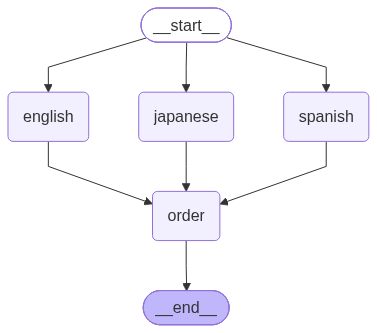

In [9]:
from typing import TypedDict
class State(TypedDict):
    sentence: str
    translations: Annotated[list, operator.add]
    ordered_result: str

def translate_en(state: State):
    result = llm.invoke(
        f"다음 문장을 영어로 자연스럽게 번역해줘. 번역문만 출력해.\n\n"
        f"{state['sentence']}"
    )

    return {
        "translations": [(0, "영어", result.text)]
    }

def translate_jp(state: State):
    result = llm.invoke(
        f"다음 문장을 일본어로 자연스럽게 번역해줘. 번역문만 출력해.\n\n"
        f"{state['sentence']}"
    )

    return {
        "translations": [(1, "일본어", result.text)]
    }

def translate_sp(state: State):
    result = llm.invoke(
        f"다음 문장을 스페인어로 자연스럽게 번역해줘. 번역문만 출력해.\n\n"
        f"{state['sentence']}"
    )

    return {
        "translations": [(2, "스페인어", result.text)]
    }

def ordered_summarize(state: State):
    # 순서대로 정렬
    sorted_translations = sorted(state["translations"], key=lambda x: x[0])
    print("정렬된 순서:")

    ordered_result = "\n\n".join(
        f"[{language}] {content}"
        for _, language, content in sorted_translations
    )
    
    return {"ordered_result": ordered_result}

graph_builder = StateGraph(State)

graph_builder.add_node("english", translate_en)
graph_builder.add_node("japanese", translate_jp)
graph_builder.add_node("spanish", translate_sp)
graph_builder.add_node("order", ordered_summarize)

graph_builder.add_edge(START, "english")
graph_builder.add_edge(START, "japanese")
graph_builder.add_edge(START, "spanish")


graph_builder.add_edge(
    ["english", "japanese", "spanish"],
    "order",
)
graph_builder.add_edge("order", END)

translation_graph = graph_builder.compile()

display(Image(translation_graph.get_graph().draw_mermaid_png()))

In [10]:
sentence = "인공지능은 우리의 일상과 업무 방식을 빠르게 변화시키고 있습니다."

result = translation_graph.invoke({
    "sentence": sentence,
    "translations": [],
})

print(result["ordered_result"])

정렬된 순서:
[영어] Artificial intelligence is rapidly changing our daily lives and the way we work.

[일본어] 人工知能は私たちの日常や働き方を急速に変化させています。

[스페인어] La inteligencia artificial está cambiando rápidamente nuestra vida cotidiana y nuestra forma de trabajar.


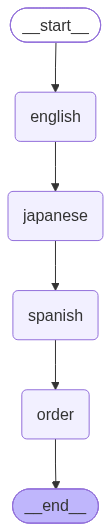

In [11]:
sequential_builder = StateGraph(State)

sequential_builder.add_node("english", translate_en)
sequential_builder.add_node("japanese", translate_jp)
sequential_builder.add_node("spanish", translate_sp)
sequential_builder.add_node("order", ordered_summarize)

sequential_builder.add_edge(START, "english")
sequential_builder.add_edge("english", "japanese")
sequential_builder.add_edge("japanese", "spanish")
sequential_builder.add_edge("spanish", "order")
sequential_builder.add_edge("order", END)

sequential_graph = sequential_builder.compile()

display(
    Image(
        sequential_graph.get_graph().draw_mermaid_png()
    )
)

In [13]:
sentence = "인공지능은 우리의 일상과 업무 방식을 빠르게 변화시키고 있습니다."

result = sequential_graph.invoke({
    "sentence": sentence,
    "translations": [],
})

print(result["ordered_result"])

정렬된 순서:
[영어] Artificial intelligence is rapidly changing our daily lives and the way we work.

[일본어] 人工知能は私たちの日常や働き方を急速に変化させています。

[스페인어] La inteligencia artificial está cambiando rápidamente nuestra vida cotidiana y la forma en que trabajamos.
